# 02 · Modelling - which model family forecasts tomorrow best, and why

This notebook turns the findings of `01_eda.ipynb` into a model choice. It compares **14 models from 6 families**
under one honest, production-like backtest, and ends with a recommendation for review.

### The forecasting contract

| | |
|---|---|
| **What** | 24 hourly values of city-wide demand (m³/h) for **tomorrow (D+1), 00:00-23:00 local** |
| **When** | issued once a day, in the **morning of D** |
| **Known at issue time** | actuals up to the **end of D−1**; the weather forecast for D+1 (issued 06:00 on D); calendar |
| **Not known** | anything that happens on D, including **today's demand**, so `lag_24h` is not allowed (min lag = 48 h) |

### Why no `lag_24`?
For a target hour on D+1, “24 hours earlier” is the same hour **today**. At issue time that hour has not happened
yet. A model given `lag_24` would score well in a backtest and then fail in production, because the value
does not exist when the forecast is made. `features.py` enforces this (`min_lag_hours = 48`).
**Section 6** measures how much accuracy `lag_24` *would* add if the forecast were issued at midnight with
real-time SCADA data, so that the issue time can be decided on evidence.

### How models are compared
* **Rolling-origin backtest over a full year:** 12 monthly folds from **Oct 2025 to Sep 2026**. Each fold is
  trained only on data available before it (training ends 2 days before the fold starts, like a real issue) and
  covers the summer peak, Ramadan 2026, both Eids and the winter low.
* **Metrics:** **MAPE** (headline), **WAPE**, RMSE, **bias** (systematic over/under-forecast), **peak-hour MAPE**
  (top 10 % demand hours: what pumping and storage planning care about) and **daily-total error** (volume
  planning).
* Every model sees exactly the same test hours. Predictions are cached in `data/cache/backtest/`, and every
  model's results are logged to **MLflow**.

## 0. Setup

In [1]:
import os
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.stats import norm
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from torch import nn

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from water_forecasting import features as F  # noqa: E402
from water_forecasting.config import ProjectConfig  # noqa: E402
from water_forecasting.exploration import load_source  # noqa: E402
from water_forecasting.modeling import SeasonalNaive, evaluate, make_model  # noqa: E402

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (14, 4.5), "axes.titleweight": "bold",
                     "axes.titlesize": 12, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 40, "display.width", 200)
torch.set_num_threads(min(8, os.cpu_count() or 1))

CACHE = ROOT / "data" / "cache" / "backtest"
CACHE.mkdir(parents=True, exist_ok=True)
FORCE_RETRAIN = False   # True = ignore cached backtest predictions and retrain every model
ONE = pd.Timedelta(days=1)

## 1. Data preparation

The same raw source tables as the production pipeline, cleaned with the **production quality rules** (nulls and
out-of-range readings) **plus the stuck-meter rule** recommended by the EDA. Features come from the production
feature code (`features.build_features`), so every model is evaluated on the features production would compute.

In [2]:
cfg = ProjectConfig.from_yaml(ROOT / "project_config.yml", env="prod")
try:
    spark  # noqa: B018
except NameError:
    spark = None
raw = load_source(cfg, spark=spark, cache_dir=ROOT / "data" / "cache")
cons, wx, fcst, cal = raw["consumption"], raw["weather_obs"], raw["weather_fcst"], raw["calendar"]

q = cfg.quality
invalid = cons.demand_m3h.isna() | (cons.demand_m3h < q.demand_min_m3h) | (cons.demand_m3h > q.demand_max_m3h)
same = cons.demand_m3h.diff().eq(0)
run_id = (same != same.shift()).cumsum()
frozen = same & same.groupby(run_id).transform("sum").ge(2)
frozen = frozen | frozen.shift(-1, fill_value=False)
clean = cons[~invalid & ~frozen].reset_index(drop=True)
print(f"removed {int(invalid.sum())} invalid + {int(frozen.sum())} frozen readings -> {len(clean):,} clean hours")

removed 67 invalid + 9 frozen readings -> 24,020 clean hours


### Feature sets
* **v1 - the original production features** (37 columns): lags 48-504 h, 7-day rolling stats, 3-week same-hour
  mean, weather forecast (+ cooling degree at 20 °C, heating degree at 12 °C), calendar, Ramadan, school break,
  event types, Fourier terms.
* **v2 - v1 + EDA-driven additions** (all known at issue time). Following this notebook, v2 is now what
  `features.build_features()` produces in production; v1 is recovered here by dropping the additions:
  * `fc_cdd24_hour`, `fc_cdd24_day`: cooling degrees at the **24.4 °C knot** found in the EDA (hourly and daily mean)
  * `fc_tmean_day`: forecast daily mean temperature for D+1
  * `fc_tmean_prev_day`: forecast mean temperature for D (issued 06:00 on D−1): **temperature persistence**
  * `obs_tmean_d2`: **observed** mean temperature of D−1 (complete at issue time)
  * `is_eid`: Eid al-Fitr / Eid al-Adha days (the only large holiday effects)

In [3]:
X = F.build_features(F.hourly_targets("2024-01-22", "2026-09-30"), clean, fcst, cal, wx)   # production code

V2_EXTRA = ["fc_tmean_day", "fc_cdd24_day", "fc_cdd24_hour", "fc_tmean_prev_day", "obs_tmean_d2", "is_eid"]
V2 = F.feature_columns()
V1 = [c for c in V2 if c not in V2_EXTRA]
LEVEL = F.LEVEL_FEATURES

# daily aggregates reused by the classical and sequence models below
fc_day_mean = fcst.groupby(fcst.timestamp_local.dt.normalize()).forecast_temperature_c.mean()
obs_day_mean = wx.groupby(wx.timestamp_local.dt.normalize()).temperature_c.mean()
holiday_names = cal.set_index("date").holiday_name.fillna("")
data = F.attach_label(X, clean)
print(f"feature rows {len(X):,}  |  labelled rows {len(data):,}  |  v1 {len(V1)} features, v2 {len(V2)} features")
print("max lag used:", max(int(c[4:-1]) for c in LEVEL if c.startswith("lag_")), "h | min lag:",
      min(int(c[4:-1]) for c in LEVEL if c.startswith("lag_")), "h")

feature rows 23,592  |  labelled rows 23,516  |  v1 37 features, v2 43 features
max lag used: 504 h | min lag: 48 h


## 2. Backtest harness

`backtest()` trains a fresh model per fold on everything available before the fold, predicts the fold, caches the
predictions and logs to MLflow. `score()` computes every metric from cached predictions.

In [4]:
FOLD_STARTS = pd.date_range("2025-10-01", "2026-09-01", freq="MS")

def folds():
    for m in FOLD_STARTS:
        te = data[(data.target_ts >= m) & (data.target_ts < m + pd.offsets.MonthBegin(1))]
        tr = data[data.target_ts < m - ONE]          # at the first issue of the fold, the newest actual is D-1
        yield m, tr, te

def daily_total_ape(P):
    d = P.assign(day=P.target_ts.dt.normalize()).groupby("day")[["demand_m3h", "pred"]].sum()
    return float((d.pred - d.demand_m3h).abs().div(d.demand_m3h).mean() * 100)

def score(P):
    m = evaluate(P.demand_m3h, P.pred)
    m["daily_total_ape"] = daily_total_ape(P)
    return m

if spark is None:
    mlflow.set_tracking_uri(f"sqlite:///{(ROOT / 'data' / 'mlflow.db').as_posix()}")
    mlflow.set_experiment("water_model_selection")
else:
    mlflow.set_experiment(f"/Users/{spark.sql('select current_user()').first()[0]}/water_model_selection")

RESULTS = {}

def backtest(name, factory, family, description):
    path = CACHE / f"{name}.parquet"
    t0 = time.time()
    if path.exists() and not FORCE_RETRAIN:
        P = pd.read_parquet(path)
    else:
        parts = []
        for m, tr, te in folds():
            model = factory().fit(tr, tr.demand_m3h)
            parts.append(te[["target_ts", "demand_m3h"]].assign(pred=model.predict(te), fold=m))
        P = pd.concat(parts, ignore_index=True)
        secs = time.time() - t0
        P.assign(fit_seconds=secs).to_parquet(path)
    if "fit_seconds" in P:
        secs = float(P.fit_seconds.iloc[0])
    P = P[["target_ts", "demand_m3h", "pred", "fold"]]
    m = score(P)
    RESULTS[name] = {"family": family, "description": description, "P": P, "metrics": m, "seconds": secs}
    with mlflow.start_run(run_name=name):
        mlflow.set_tags({"family": family, "description": description, "backtest": "12 monthly folds Oct25-Sep26"})
        mlflow.log_metrics({k: float(v) for k, v in m.items()} | {"backtest_seconds": secs})
    print(f"{name:24s} MAPE {m['mape']:5.2f} %  bias {m['bias_pct']:+5.2f} %  peak {m['peak_mape']:5.2f} %  "
          f"daily {m['daily_total_ape']:4.2f} %  ({secs:,.0f}s)")
    return P

### Growth-aware wrapper (trend normalisation)

The EDA found **~10 %/yr growth**. A model trained on the past cannot predict levels it has never seen, and tree
models in particular cannot extrapolate. `TrendNormalized` fits a **growth trend on the training history only**,
divides the target and every level-type feature (lags, rolling means) by it, lets the model learn the
*shape and relative effects*, and multiplies the prediction back by the extrapolated trend. It can wrap any model.

The trend is the **production function** `modeling.fit_growth_trend`: log daily demand ~ a + b·t, with **annual
harmonics as nuisance terms**, so the summer/winter swing is not mistaken for growth. Only the growth part
exp(a + b·t) is used. With less than **18 months** of history the slope is set to 0, because growth and one annual
cycle cannot be separated; a dev deployment with 8 months of history made the unguarded version extrapolate the
winter-to-summer ramp as growth.

In [5]:
from water_forecasting.modeling import fit_growth_trend

DAY0 = F.EPOCH

def fit_trend(ts, y):
    t = (pd.DatetimeIndex(ts) - DAY0).total_seconds().to_numpy() / 86400
    a, b = fit_growth_trend(t, y)
    return lambda tt: np.exp(a + b * ((pd.DatetimeIndex(tt) - DAY0).total_seconds().to_numpy() / 86400))

class TrendNormalized:
    def __init__(self, model, cols):
        self.model, self.cols = model, cols

    def _x(self, X):
        tr = self.trend_(X.target_ts)
        Z = X[self.cols].copy()
        for col in LEVEL:
            if col in Z:
                Z[col] = Z[col] / tr
        return Z, tr

    def fit(self, X, y):
        self.trend_ = fit_trend(X.target_ts, y)
        Z, tr = self._x(X)
        self.model.fit(Z, np.asarray(y) / tr)
        return self

    def predict(self, X):
        Z, tr = self._x(X)
        return self.model.predict(Z) * tr

class OnCols:
    # restrict a production model to a column set (keeps the harness uniform)
    def __init__(self, model, cols):
        self.model, self.cols = model, cols
    def fit(self, X, y):
        self.model.fit(X[self.cols], y); return self
    def predict(self, X):
        return self.model.predict(X[self.cols])

LGBM = cfg.model.lgbm_params

## 3. Model families

### 3.1 Baselines - the bar every model must clear

In [6]:
backtest("naive_48h", lambda: OnCols(make_model("seasonal_naive_48"), V1), "baseline",
         "same hour on D-1 (lag 48h)")
backtest("naive_168h", lambda: OnCols(make_model("seasonal_naive_168"), V1), "baseline",
         "same hour last week (production sanity baseline)")
backtest("naive_3w_mean", lambda: OnCols(SeasonalNaive("same_hour_mean_3w", "lag_168h"), V1), "baseline",
         "mean of the same hour 1, 2 and 3 weeks ago");

naive_48h                MAPE  6.47 %  bias -0.03 %  peak  5.38 %  daily 3.91 %  (0s)
naive_168h               MAPE  5.94 %  bias -0.04 %  peak  5.51 %  daily 4.67 %  (0s)
naive_3w_mean            MAPE  6.19 %  bias -0.19 %  peak  5.60 %  daily 4.61 %  (0s)


### 3.2 Classical statistics - SARIMA / SARIMAX on daily totals + intraday profile

The traditional utility approach, **top-down**:
1. Forecast the **daily mean** with a seasonal ARIMA on log demand, (1,1,1)×(1,0,1)₇. The EDA showed the daily
   level needs one difference (d = 1) and has a weekly season.
2. Split it into 24 hours with the **average intraday profile of the last 8 days of the same type**
   (Ramadan / non-Ramadan × working day / day off). For the first days of Ramadan this uses last year's Ramadan.

Each day the model is re-filtered with actuals up to D−1 (no refit) and forecasts **two steps ahead** (D, then
D+1). **SARIMAX** adds known-in-advance drivers from the EDA: forecast cooling degrees (24.4 °C knot), day off,
Friday, Saturday, Eid, Ramadan, flood/recovery flag. Hourly SARIMA with 24- and 168-hour seasons is impractical
to fit on 20k+ hours, which is why the daily top-down design is standard.

In [7]:
s_all = clean.set_index("timestamp_local").demand_m3h.asfreq("h")
daily_mean = s_all.resample("D").mean().interpolate()
calx = cal.set_index("date")

exog = pd.DataFrame(index=daily_mean.index)
exog["cdd"] = (fc_day_mean.reindex(exog.index) - 24.4).clip(lower=0)
exog["dayoff"] = (calx.is_weekend | calx.is_public_holiday).reindex(exog.index).astype(float)
exog["fri"] = (exog.index.dayofweek == 4).astype(float)
exog["sat"] = (exog.index.dayofweek == 5).astype(float)
exog["eid"] = holiday_names.str.contains("Eid").reindex(exog.index).astype(float)
exog["ramadan"] = calx.is_ramadan.reindex(exog.index).astype(float)
exog["flood"] = calx.event_type.isin(["weather", "operational"]).reindex(exog.index).astype(float)
exog = exog.ffill()

rel = (s_all / s_all.resample("D").transform("mean")).to_frame("r")
profiles = rel.assign(day=rel.index.normalize(), hour=rel.index.hour).pivot_table(index="day", columns="hour", values="r")
day_class = pd.Series(list(zip(calx.is_ramadan, calx.is_weekend | calx.is_public_holiday)), index=calx.index)

def intraday_profile(T, last_complete):
    hist = profiles.loc[:last_complete].dropna()
    same_type = hist[day_class.reindex(hist.index) == day_class[T]]
    p = (same_type.tail(8) if len(same_type) >= 3 else hist.tail(8)).mean()
    return (p / p.mean()).to_numpy()

class DailySARIMAX:
    def __init__(self, exog_cols=None):
        self.cols = exog_cols

    def _ex(self, end):
        return None if not self.cols else exog[self.cols][:end]

    def fit(self, X, y):
        self.end_ = X.target_ts.max().normalize()
        self.res_ = SARIMAX(np.log(daily_mean[:self.end_]), exog=self._ex(self.end_), order=(1, 1, 1),
                            seasonal_order=(1, 0, 1, 7)).fit(disp=False)
        return self

    def predict(self, X):
        out = []
        for T in sorted(X.target_ts.dt.normalize().unique()):
            lc = T - 2 * ONE                                  # newest complete day at issue time
            r = self.res_.apply(np.log(daily_mean[:lc]), exog=self._ex(lc), refit=False)
            fut = None if not self.cols else exog[self.cols].loc[lc + ONE:T]
            level = np.exp(r.forecast(2, exog=fut).iloc[-1])
            out.append(pd.Series(level * intraday_profile(T, lc), index=pd.date_range(T, periods=24, freq="h")))
        return pd.concat(out).reindex(X.target_ts).to_numpy()

backtest("sarima_daily", lambda: DailySARIMAX(), "classical", "SARIMA(1,1,1)(1,0,1)7 on log daily mean + profile")
backtest("sarimax_daily", lambda: DailySARIMAX(["cdd", "dayoff", "fri", "sat", "eid", "ramadan", "flood"]),
         "classical", "SARIMAX with weather/calendar drivers + profile");

sarima_daily             MAPE  3.72 %  bias -0.01 %  peak  3.98 %  daily 3.20 %  (15s)
sarimax_daily            MAPE  2.85 %  bias -0.41 %  peak  2.81 %  daily 2.10 %  (24s)


### 3.3 Linear models

* **Ridge-Fourier (production):** a linear model on v1 features, raw target.
* **Ridge + interactions (trend-normalised, v2):** the EDA showed that Ramadan and days off *reshape the day* and
  that heat lifts some hours more than others. A linear model cannot learn that unless it is given the terms, so
  we add **hour one-hot × day-off**, **hour × Ramadan** and **hour × cooling degree** interactions (72 extra columns).

In [8]:
class RidgeInteractions:
    def __init__(self, alpha=3.0):
        self.alpha = alpha

    def _design(self, Z):
        H = np.eye(24)[Z["hour"].astype(int).to_numpy()]
        base = Z.drop(columns=["hour", "day_of_week", "month"])
        inter = np.hstack([H * Z[["is_day_off"]].to_numpy(), H * Z[["is_ramadan"]].to_numpy(),
                           H * Z[["fc_cdd24_hour"]].fillna(0).to_numpy()])
        return np.hstack([base.to_numpy(float), H, inter])

    def fit(self, Z, y):
        self.pipe_ = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=self.alpha))
        self.pipe_.fit(self._design(Z), y); return self

    def predict(self, Z):
        return self.pipe_.predict(self._design(Z))

backtest("ridge_fourier_prod", lambda: OnCols(make_model("ridge_fourier"), V1), "linear",
         "production Ridge-Fourier, raw target, v1")
backtest("ridge_interactions", lambda: TrendNormalized(RidgeInteractions(), V2), "linear",
         "Ridge + hour x (day-off, Ramadan, cooling) interactions, trend-normalised, v2");

ridge_fourier_prod       MAPE  4.48 %  bias -1.06 %  peak  4.42 %  daily 2.67 %  (1s)


ridge_interactions       MAPE  2.64 %  bias +0.12 %  peak  2.61 %  daily 1.89 %  (4s)


### 3.4 Tree ensembles - boosting and bagging

A ladder of LightGBM variants isolates the value of each change, plus a Random Forest as the bagging family:

| model | target | features |
|---|---|---|
| `lgbm_prod` | raw (as in production) | v1 |
| `lgbm_trend_v1` | trend-normalised | v1 |
| `lgbm_trend_v2` | trend-normalised | v2 |
| `random_forest` | trend-normalised | v2 |

In [9]:
def rf():
    return make_pipeline(SimpleImputer(strategy="median"),
                         RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=0.5,
                                               n_jobs=-1, random_state=42))

backtest("lgbm_prod", lambda: OnCols(make_model("lightgbm", lgbm_params=LGBM), V1), "trees",
         "production LightGBM, raw target, v1")
backtest("lgbm_trend_v1", lambda: TrendNormalized(make_model("lightgbm", lgbm_params=LGBM), V1), "trees",
         "LightGBM, trend-normalised, v1")
backtest("lgbm_trend_v2", lambda: TrendNormalized(make_model("lightgbm", lgbm_params=LGBM), V2), "trees",
         "LightGBM, trend-normalised, v2")
backtest("random_forest", lambda: TrendNormalized(rf(), V2), "trees", "Random Forest, trend-normalised, v2");

lgbm_prod                MAPE  3.44 %  bias -1.34 %  peak  4.04 %  daily 2.52 %  (15s)


lgbm_trend_v1            MAPE  2.91 %  bias +0.19 %  peak  2.81 %  daily 2.03 %  (19s)


lgbm_trend_v2            MAPE  2.90 %  bias +0.16 %  peak  2.66 %  daily 1.98 %  (22s)


random_forest            MAPE  3.48 %  bias +0.47 %  peak  3.28 %  daily 2.38 %  (44s)


### 3.5 Deep learning (PyTorch)

**MLP (tabular):** a feed-forward network on the same trend-normalised v2 features as `lgbm_trend_v2`
(128 → 64 units, ReLU, dropout 0.1, L1 loss, the robust analogue of MAPE on a normalised target). Early stopping on
the last 6 weeks of each training window; **3 random seeds averaged** (neural nets vary by seed; averaging is the
cheap, standard remedy).

**GRU sequence-to-sequence:** a real time-series architecture.
* **Encoder:** a GRU over the **last 7 complete days (D−7 … D−1)**. Each day is one token: its 24 trend-normalised
  hourly values plus day type, Ramadan flag and observed temperature. Seven tokens instead of 168 hours keeps the
  sequence short enough to learn from ~600 training days.
* **Decoder:** a bidirectional GRU over the 24 target hours of D+1, fed the known-in-advance covariates (weather
  forecast, calendar, Fourier terms) plus the **aligned lags of each target hour**. It starts from the encoder state.
* **Output:** a **correction to the 3-week same-hour mean** (residual learning), so the network only learns
  deviations from a sensible baseline. L1 loss, early stopping, 3 seeds averaged.

In [10]:
class MLPForecaster:
    def __init__(self, cols, seeds=(0, 1, 2), epochs=80):
        self.cols, self.seeds, self.epochs = cols, seeds, epochs

    def _prep(self, X, fit=False):
        tr = self.trend_(X.target_ts)
        Z = X[self.cols].copy()
        for col in LEVEL:
            Z[col] = Z[col] / tr
        if fit:
            self.med_ = Z.median()
            filled = Z.fillna(self.med_)
            self.mu_, self.sd_ = filled.mean(), filled.std().replace(0, 1)
        Z = (Z.fillna(self.med_) - self.mu_) / self.sd_
        return torch.tensor(Z.to_numpy(np.float32)), tr

    def fit(self, X, y):
        self.trend_ = fit_trend(X.target_ts, y)
        Z, tr = self._prep(X, fit=True)
        r = torch.tensor((np.asarray(y) / tr).astype(np.float32))
        val = (X.target_ts >= X.target_ts.max() - pd.Timedelta(days=42)).to_numpy()
        tri = np.where(~val)[0]
        self.nets_ = []
        for seed in self.seeds:
            torch.manual_seed(seed)
            net = nn.Sequential(nn.Linear(Z.shape[1], 128), nn.ReLU(), nn.Dropout(0.1),
                                nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
            opt = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)
            best, state, wait = np.inf, None, 0
            for ep in range(self.epochs):
                net.train()
                perm = np.random.default_rng(seed * 1000 + ep).permutation(tri)
                for i in range(0, len(perm), 256):
                    b = perm[i:i + 256]
                    loss = (net(Z[b]).squeeze(1) - r[b]).abs().mean()
                    opt.zero_grad(); loss.backward(); opt.step()
                net.eval()
                with torch.no_grad():
                    v = (net(Z[val]).squeeze(1) - r[val]).abs().mean().item()
                if v < best - 1e-5:
                    best, state, wait = v, {k: t.clone() for k, t in net.state_dict().items()}, 0
                else:
                    wait += 1
                    if wait >= 8:
                        break
            net.load_state_dict(state)
            self.nets_.append(net.eval())
        return self

    def predict(self, X):
        Z, tr = self._prep(X)
        with torch.no_grad():
            return np.mean([n(Z).squeeze(1).numpy() for n in self.nets_], axis=0) * tr

In [11]:
X_by_ts = X.set_index("target_ts")
DEC = [c for c in V2 if c not in LEVEL]

class DayTokenSeq2Seq(nn.Module):
    def __init__(self, enc_in, dec_in, hidden=32, dropout=0.3):
        super().__init__()
        self.encoder = nn.GRU(enc_in, hidden, batch_first=True)
        self.bridge = nn.Linear(hidden, 2 * hidden)
        self.decoder = nn.GRU(dec_in, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(2 * hidden, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, enc_x, dec_x, baseline):
        _, h = self.encoder(enc_x)
        h0 = torch.tanh(self.bridge(h[-1])).view(-1, 2, h.shape[-1]).transpose(0, 1).contiguous()
        out, _ = self.decoder(dec_x, h0)
        return baseline + self.head(out).squeeze(-1)          # residual on the 3-week same-hour mean

class GRUSeq2Seq:
    def __init__(self, seeds=(0, 1, 2), epochs=120):
        self.seeds, self.epochs = seeds, epochs

    def _samples(self, days, fit=False):
        E, D, B, Y = [], [], [], []
        for T in days:
            enc_days = pd.date_range(T - 8 * ONE, T - 2 * ONE)            # D-7 .. D-1
            hrs = pd.date_range(enc_days[0], enc_days[-1] + pd.Timedelta(hours=23), freq="h")
            yv = pd.Series(s_all.reindex(hrs).to_numpy() / self.trend_(hrs)).interpolate(limit_direction="both")
            cx = calx.reindex(enc_days)
            day_feats = np.column_stack([np.sin(2 * np.pi * enc_days.dayofweek / 7),
                                         np.cos(2 * np.pi * enc_days.dayofweek / 7),
                                         (cx.is_weekend | cx.is_public_holiday).to_numpy(float),
                                         cx.is_ramadan.to_numpy(float),
                                         (obs_day_mean.reindex(enc_days).to_numpy() - 32) / 7])
            E.append(np.concatenate([yv.fillna(1.0).to_numpy().reshape(7, 24), day_feats], axis=1))
            th = pd.date_range(T, periods=24, freq="h")
            fx, tr_t = X_by_ts.reindex(th), self.trend_(th)
            base = fx.same_hour_mean_3w.fillna(fx.lag_168h).to_numpy() / tr_t
            B.append(np.nan_to_num(base, nan=np.nanmean(base) if np.isfinite(base).any() else 1.0))
            D.append(np.concatenate([fx[DEC].to_numpy(), fx[LEVEL].to_numpy() / tr_t[:, None]], axis=1))
            Y.append(s_all.reindex(th).to_numpy() / tr_t)
        E, D, B, Y = (np.array(a, np.float32) for a in (E, D, B, Y))
        if fit:
            flat = D.reshape(-1, D.shape[-1])
            self.med_, self.mu_, self.sd_ = np.nanmedian(flat, 0), np.nanmean(flat, 0), np.nanstd(flat, 0)
            self.sd_[self.sd_ == 0] = 1
        D = (np.where(np.isnan(D), self.med_, D) - self.mu_) / self.sd_
        return torch.tensor(E), torch.tensor(D), torch.tensor(B), torch.tensor(Y)

    def fit(self, X, y):
        self.trend_ = fit_trend(X.target_ts, y)
        days = pd.DatetimeIndex(sorted(X.target_ts.dt.normalize().unique()))
        days = days[days >= pd.Timestamp("2024-02-12")]
        E, D, B, Y = self._samples(days, fit=True)
        M = ~torch.isnan(Y); Y = torch.nan_to_num(Y, nan=1.0)
        val = np.asarray(days >= days.max() - 42 * ONE)
        tri = np.where(~val)[0]
        self.nets_ = []
        for seed in self.seeds:
            torch.manual_seed(seed)
            net = DayTokenSeq2Seq(E.shape[-1], D.shape[-1])
            opt = torch.optim.AdamW(net.parameters(), lr=2e-3, weight_decay=1e-2)
            best, state, wait = np.inf, None, 0
            for ep in range(self.epochs):
                net.train()
                perm = np.random.default_rng(seed * 1000 + ep).permutation(tri)
                for i in range(0, len(perm), 32):
                    b = perm[i:i + 32]
                    loss = ((net(E[b], D[b], B[b]) - Y[b]).abs() * M[b]).sum() / M[b].sum()
                    opt.zero_grad(); loss.backward(); opt.step()
                net.eval()
                with torch.no_grad():
                    v = ((net(E[val], D[val], B[val]) - Y[val]).abs() * M[val]).sum().item() / M[val].sum().item()
                if v < best - 1e-5:
                    best, state, wait = v, {k: t.clone() for k, t in net.state_dict().items()}, 0
                else:
                    wait += 1
                    if wait >= 12:
                        break
            net.load_state_dict(state)
            self.nets_.append(net.eval())
        return self

    def predict(self, X):
        days = pd.DatetimeIndex(sorted(X.target_ts.dt.normalize().unique()))
        E, D, B, _ = self._samples(days)
        with torch.no_grad():
            r = np.mean([n(E, D, B).numpy() for n in self.nets_], axis=0)
        idx = pd.DatetimeIndex(np.concatenate([pd.date_range(T, periods=24, freq="h") for T in days]))
        return pd.Series(r.reshape(-1) * self.trend_(idx), index=idx).reindex(X.target_ts).to_numpy()

In [12]:
backtest("mlp", lambda: MLPForecaster(V2), "deep learning", "MLP 128-64, trend-normalised v2, 3 seeds")
backtest("gru_seq2seq", lambda: GRUSeq2Seq(), "deep learning",
         "GRU encoder (7 day-tokens) -> BiGRU decoder (24h), residual on 3-week mean, 3 seeds");

mlp                      MAPE  2.65 %  bias -0.08 %  peak  2.76 %  daily 1.74 %  (151s)


gru_seq2seq              MAPE  2.73 %  bias +0.11 %  peak  2.74 %  daily 1.76 %  (832s)


### 3.6 Ensemble

Models from different families make different mistakes, so averaging them usually helps. To avoid picking
members *because* they did well on this test set, the ensemble is defined **by design, not by result**: the
strongest-by-design member of each of the three modern families - **trees (`lgbm_trend_v2`), classical
(`sarimax_daily`) and deep learning (`mlp`)** - equally weighted.

In [13]:
members = ["lgbm_trend_v2", "sarimax_daily", "mlp"]
base = RESULTS[members[0]]["P"][["target_ts", "demand_m3h", "fold"]].copy()
base["pred"] = np.mean([RESULTS[m]["P"].set_index("target_ts").pred.reindex(base.target_ts).to_numpy()
                        for m in members], axis=0)
m = score(base)
RESULTS["ensemble"] = {"family": "ensemble", "description": "mean of lgbm_trend_v2 + sarimax_daily + mlp",
                       "P": base, "metrics": m, "seconds": sum(RESULTS[k]["seconds"] for k in members)}
with mlflow.start_run(run_name="ensemble"):
    mlflow.set_tags({"family": "ensemble", "members": ",".join(members)})
    mlflow.log_metrics({k: float(v) for k, v in m.items()})
print(f"ensemble MAPE {m['mape']:.2f} %  bias {m['bias_pct']:+.2f} %  peak {m['peak_mape']:.2f} %  daily {m['daily_total_ape']:.2f} %")

ensemble MAPE 2.51 %  bias -0.11 %  peak 2.56 %  daily 1.72 %


## 4. Leaderboard

In [14]:
board = pd.DataFrame({k: {"family": v["family"], **v["metrics"], "backtest_s": v["seconds"],
                          "description": v["description"]} for k, v in RESULTS.items()}).T
num = ["mape", "wape", "rmse", "bias_pct", "peak_mape", "daily_total_ape", "backtest_s"]
board[num] = board[num].astype(float)
board = board.sort_values("mape")
prod = board.loc["lgbm_prod", "mape"]
board["vs_production_%"] = (board.mape / prod - 1) * 100
board[["family", "mape", "wape", "rmse", "bias_pct", "peak_mape", "daily_total_ape", "vs_production_%",
       "backtest_s", "description"]].round(2)

,family,mape,wape,rmse,bias_pct,peak_mape,daily_total_ape,vs_production_%,backtest_s,description
ensemble,ensemble,2.51,2.49,3754.58,-0.11,2.56,1.72,-27.06,196.93,mean of lgbm_trend_v2 + sarimax_daily + mlp
ridge_interactions,linear,2.64,2.61,3898.43,0.12,2.61,1.89,-23.23,3.54,"Ridge + hour x (day-off, Ramadan, cooling) int..."
mlp,deep learning,2.65,2.63,3981.57,-0.08,2.76,1.74,-22.95,151.21,"MLP 128-64, trend-normalised v2, 3 seeds"
gru_seq2seq,deep learning,2.73,2.69,4252.10,0.11,2.74,1.76,-20.53,832.18,GRU encoder (7 day-tokens) -> BiGRU decoder (2...
sarimax_daily,classical,2.85,2.85,4291.35,-0.41,2.81,2.10,-17.01,23.64,SARIMAX with weather/calendar drivers + profile
lgbm_trend_v2,trees,2.90,2.86,4335.68,0.16,2.66,1.98,-15.58,22.08,"LightGBM, trend-normalised, v2"
lgbm_trend_v1,trees,2.91,2.87,4358.50,0.19,2.81,2.03,-15.24,18.52,"LightGBM, trend-normalised, v1"
lgbm_prod,trees,3.44,3.43,5180.76,-1.34,4.04,2.52,0.00,15.18,"production LightGBM, raw target, v1"
random_forest,trees,3.48,3.41,5343.44,0.47,3.28,2.38,1.31,43.84,"Random Forest, trend-normalised, v2"
sarima_daily,classical,3.72,3.73,5698.14,-0.01,3.98,3.20,8.19,14.66,"SARIMA(1,1,1)(1,0,1)7 on log daily mean + profile"


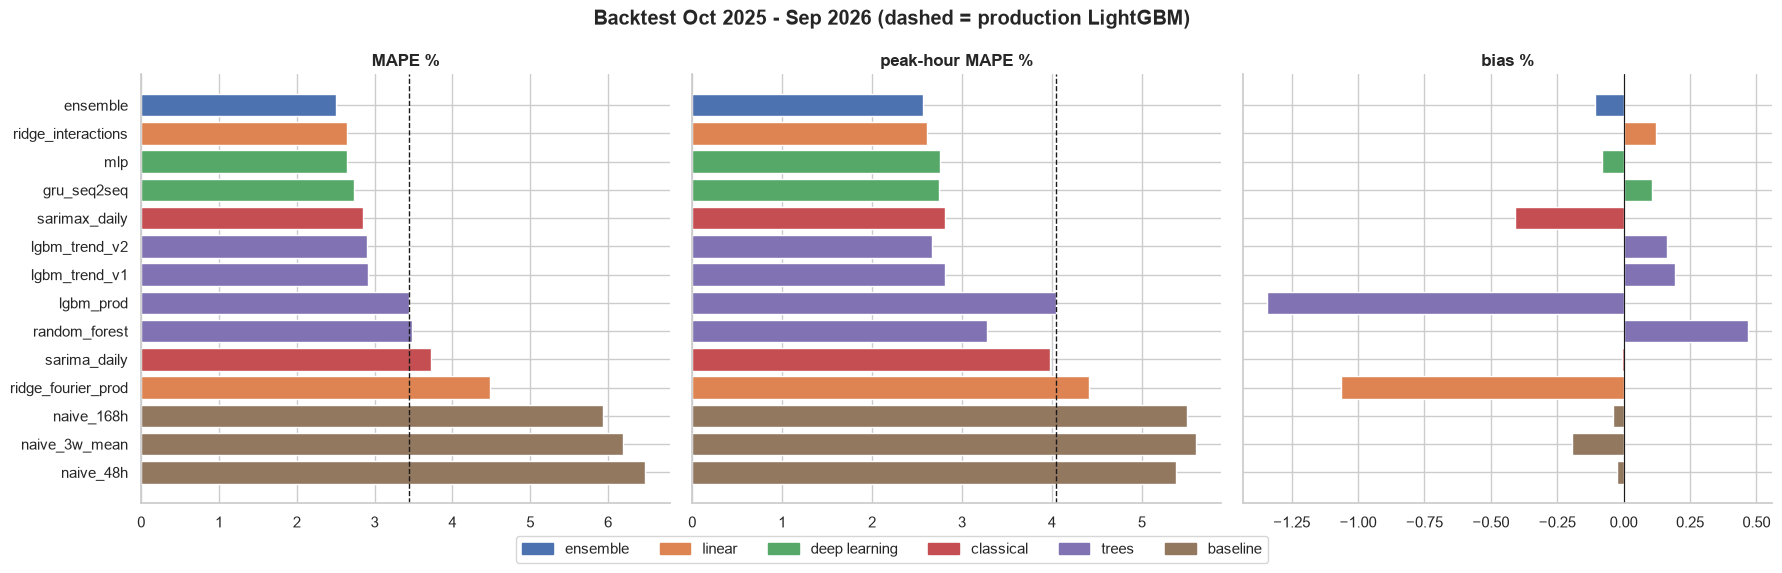

In [15]:
colors = dict(zip(board.family.unique(), sns.color_palette("deep", board.family.nunique())))
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
for ax, col, title in zip(axes, ["mape", "peak_mape", "bias_pct"], ["MAPE %", "peak-hour MAPE %", "bias %"]):
    ax.barh(board.index, board[col], color=[colors[f] for f in board.family])
    ax.set_title(title); ax.invert_yaxis() if ax is axes[0] else None
    if col == "bias_pct":
        ax.axvline(0, color="k", lw=0.8)
    else:
        ax.axvline(prod if col == "mape" else board.loc["lgbm_prod", col], color="k", ls="--", lw=1)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
fig.legend(handles, colors.keys(), loc="lower center", ncol=len(colors), bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Backtest Oct 2025 - Sep 2026 (dashed = production LightGBM)", fontweight="bold")
plt.tight_layout(); plt.show()

### 4.1 Stability across the 12 folds

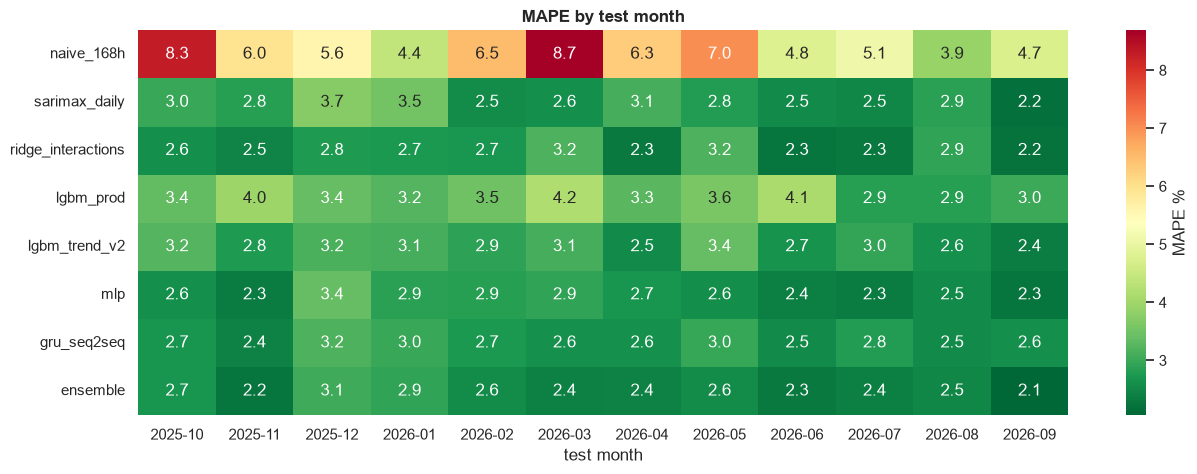

,mean,std,worst_month,months_best
ensemble,2.50,0.28,3.05,5.0
ridge_interactions,2.64,0.34,3.19,6.0
mlp,2.65,0.32,3.38,0.0
gru_seq2seq,2.73,0.22,3.19,0.0
sarimax_daily,2.85,0.44,3.71,1.0
lgbm_trend_v2,2.90,0.31,3.39,0.0
lgbm_trend_v1,2.91,0.33,3.28,0.0
lgbm_prod,3.44,0.45,4.16,0.0
random_forest,3.48,0.58,4.61,0.0
sarima_daily,3.71,0.74,5.22,0.0


In [16]:
fold_mape = pd.DataFrame({k: v["P"].groupby("fold").apply(lambda g: evaluate(g.demand_m3h, g.pred)["mape"])
                          for k, v in RESULTS.items()})
fold_mape.index = fold_mape.index.strftime("%Y-%m")
focus = ["naive_168h", "sarimax_daily", "ridge_interactions", "lgbm_prod", "lgbm_trend_v2", "mlp", "gru_seq2seq", "ensemble"]
fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(fold_mape[focus].T, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax, cbar_kws={"label": "MAPE %"})
ax.set(title="MAPE by test month", xlabel="test month", ylabel=""); plt.show()
stab = pd.DataFrame({"mean": fold_mape.mean(), "std": fold_mape.std(), "worst_month": fold_mape.max(),
                     "months_best": fold_mape.idxmin(axis=1).value_counts()}).fillna(0).sort_values("mean")
stab.round(2)

### 4.2 Are the differences statistically significant? (Diebold-Mariano)

Is the difference in accuracy between two models larger than chance? The **Diebold-Mariano test** compares
their **daily mean absolute % errors** (361 test days), with a Newey-West variance (7 lags) for autocorrelated
errors. p < 0.05 → the difference is unlikely to be luck.

In [17]:
def daily_loss(name):
    P = RESULTS[name]["P"]
    return (P.pred - P.demand_m3h).abs().div(P.demand_m3h).groupby(P.target_ts.dt.normalize()).mean() * 100

def diebold_mariano(a, b, lags=7):
    d = (daily_loss(a) - daily_loss(b)).dropna().to_numpy()
    n, dc = len(d), d - d.mean()
    var = dc @ dc / n + 2 * sum((1 - k / (lags + 1)) * (dc[k:] @ dc[:-k]) / n for k in range(1, lags + 1))
    stat = d.mean() / np.sqrt(var / n)
    return {"A": a, "B": b, "mean daily MAPE diff (A-B)": d.mean(), "DM stat": stat, "p-value": 2 * (1 - norm.cdf(abs(stat)))}

pairs = [("lgbm_prod", "lgbm_trend_v2"), ("lgbm_trend_v1", "lgbm_trend_v2"), ("lgbm_trend_v2", "mlp"),
         ("lgbm_trend_v2", "sarimax_daily"), ("lgbm_trend_v2", "ensemble"), ("sarimax_daily", "ensemble"),
         ("mlp", "ensemble"), ("naive_168h", "sarimax_daily")]
pd.DataFrame([diebold_mariano(a, b) for a, b in pairs]).round(4)

,A,B,mean daily MAPE diff (A-B),DM stat,p-value
0,lgbm_prod,lgbm_trend_v2,0.5394,5.1364,0.0000
1,lgbm_trend_v1,lgbm_trend_v2,0.0114,0.3875,0.6984
2,lgbm_trend_v2,mlp,0.2534,3.2592,0.0011
3,lgbm_trend_v2,sarimax_daily,0.0494,0.4717,0.6371
4,lgbm_trend_v2,ensemble,0.3945,6.4744,0.0000
5,sarimax_daily,ensemble,0.3450,5.6077,0.0000
6,mlp,ensemble,0.1410,3.0440,0.0023
7,naive_168h,sarimax_daily,3.0916,7.1367,0.0000


> **Findings - model comparison**
>
> * **Every learned model beats the naive baselines** (5.9-6.5 % MAPE), and **seven beat production LightGBM
>   (3.44 %)**. Three do not: Random Forest (3.48 %), SARIMA without drivers (3.72 %) and production Ridge (4.48 %).
> * **The diverse ensemble is best: 2.51 % MAPE, 27 % lower than production.** It also has near-zero bias (−0.11 %),
>   2.56 % peak-hour MAPE and a 1.72 % daily-volume error. Its worst month is 3.05 % (production: 4.16 %). It is the
>   best model in 5 of 12 months; `ridge_interactions` wins the other 6 plus one for SARIMAX.
> * **The differences are real, not luck (Diebold-Mariano):** the ensemble beats each of its three members
>   individually (lgbm_trend_v2 p < 0.0001, sarimax_daily p < 0.0001, mlp p = 0.002), and the MLP beats
>   LightGBM-trend (p = 0.001). LightGBM-trend and SARIMAX are statistically tied (p = 0.64).
> * **Growth-awareness is the biggest single lever, but not sufficient on its own.** The trend-normalised
>   LightGBM variants and the growth-normalised ridge all clearly beat their raw-target counterpart
>   (`lgbm_prod`, 3.44 %). But handling growth does not guarantee a win by itself: `random_forest`
>   (trend-normalised, 3.48 %) and `sarima_daily` (differenced, no drivers, 3.72 %) both still trail
>   `lgbm_prod` - the model family and the feature set matter too.
> * **A linear model with the right interactions (2.64 %, 4-second backtest) beats LightGBM (2.90 %) and matches
>   deep learning.** For one smooth city-wide series, encoding the EDA findings (hour × day-off, hour × Ramadan,
>   hour × cooling degree) beats model complexity.
> * **Deep learning is competitive but not decisive:** MLP 2.65 %, GRU seq2seq 2.73 %. The GRU needed careful
>   design (day tokens, aligned lags, residual learning) to generalise from ~600 training days, and costs ~240×
>   the compute of Ridge.
> * **Classical SARIMAX with EDA drivers (2.85 %)** is strong and interpretable. Its top-down design (daily model
>   plus intraday profile) is a different pipeline shape from the hourly models.
> * **Random Forest (3.48 %)** averages its leaves, which smooths the peaks; it has the largest positive bias.

## 5. What drives the improvement over production? (ablation)

The LightGBM ladder isolates each step, with the same model and hyper-parameters throughout.

In [18]:
ladder = ["lgbm_prod", "lgbm_trend_v1", "lgbm_trend_v2"]
lad = board.loc[ladder, ["mape", "bias_pct", "peak_mape", "daily_total_ape"]].copy()
lad["step"] = ["production (raw target, v1)", "+ trend normalisation", "+ EDA features (v2)"]
lad["MAPE gain vs previous step"] = -lad.mape.diff()
lad.set_index("step").round(3)

,mape,bias_pct,peak_mape,daily_total_ape,MAPE gain vs previous step
step,,,,,
"production (raw target, v1)",3.437,-1.342,4.045,2.523,NaN
+ trend normalisation,2.913,0.195,2.806,2.025,0.524
+ EDA features (v2),2.902,0.165,2.663,1.984,0.012


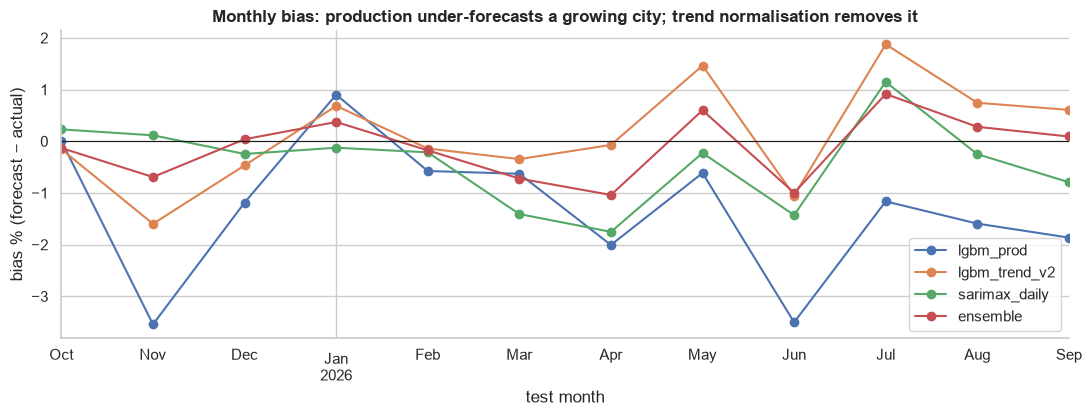

In [19]:
monthly_bias = pd.DataFrame({k: RESULTS[k]["P"].groupby("fold").apply(lambda g: evaluate(g.demand_m3h, g.pred)["bias_pct"])
                             for k in ["lgbm_prod", "lgbm_trend_v2", "sarimax_daily", "ensemble"]})
ax = monthly_bias.plot(marker="o", figsize=(13, 4))
ax.axhline(0, color="k", lw=0.8)
ax.set(title="Monthly bias: production under-forecasts a growing city; trend normalisation removes it",
       ylabel="bias % (forecast − actual)", xlabel="test month"); plt.show()

> **Findings - ablation**
>
> * **Trend normalisation is the single biggest improvement:** MAPE 3.44 → 2.91 % (−0.52 pp, DM p < 0.0001),
>   peak-hour MAPE 4.04 → 2.81 %, and the bias moves from **−1.34 % to +0.19 %**. Production under-forecasts in
>   almost every month because the city keeps setting new demand levels a raw tree model has never seen.
> * **The EDA features (v2) add only 0.01 pp to LightGBM** (not significant, p = 0.70). Trees already learn the
>   temperature hinge and holiday effects from the raw inputs. The same features are **essential for the linear
>   and classical models**: `ridge_interactions` needs the 24.4 °C cooling term, and SARIMAX needs the knot and
>   the Eid flag. Production keeps them for that reason.

## 6. The lag-24 what-if - what would a midnight issue time be worth?

**Scenario:** the forecast is issued at **00:00 on D+1** instead of the morning of D, with SCADA data for all of D
available by then. Now the same hour **24 h earlier** and **yesterday's daily level** are legitimate inputs.
We add `lag_24h` and `lag_24h_daymean` (trend-normalised) to `lgbm_trend_v2` and compare.

This model **cannot** be used with today's morning issue time. It is a what-if to support a business decision.

In [20]:
X["lag_24h"] = X.target_ts.map(s_all.shift(24))
X["lag_24h_daymean"] = (X.target_ts.dt.normalize() - ONE).map(s_all.resample("D").mean())
data["lag_24h"] = data.target_ts.map(X.set_index("target_ts").lag_24h)
data["lag_24h_daymean"] = data.target_ts.map(X.set_index("target_ts").lag_24h_daymean)
LEVEL_WITH_24 = LEVEL + ["lag_24h", "lag_24h_daymean"]

class TrendNormalized24(TrendNormalized):
    def _x(self, X):
        tr = self.trend_(X.target_ts)
        Z = X[self.cols].copy()
        for col in LEVEL_WITH_24:
            if col in Z:
                Z[col] = Z[col] / tr
        return Z, tr

backtest("WHATIF_lgbm_with_lag24", lambda: TrendNormalized24(make_model("lightgbm", lgbm_params=LGBM),
         V2 + ["lag_24h", "lag_24h_daymean"]), "what-if (not deployable)",
         "lgbm_trend_v2 + lag_24h (requires a midnight issue with real-time SCADA)")
w = RESULTS.pop("WHATIF_lgbm_with_lag24")
cmp = pd.DataFrame({"morning issue (lgbm_trend_v2)": RESULTS["lgbm_trend_v2"]["metrics"],
                    "midnight issue (+ lag 24h)": w["metrics"]}).T
cmp["mape_reduction_%"] = (1 - cmp.mape / cmp.mape.iloc[0]) * 100
cmp[["mape", "bias_pct", "peak_mape", "daily_total_ape", "mape_reduction_%"]].round(2)

WHATIF_lgbm_with_lag24   MAPE  2.78 %  bias +0.22 %  peak  2.64 %  daily 1.83 %  (91s)


,mape,bias_pct,peak_mape,daily_total_ape,mape_reduction_%
morning issue (lgbm_trend_v2),2.90,0.16,2.66,1.98,0.00
midnight issue (+ lag 24h),2.78,0.22,2.64,1.83,4.15


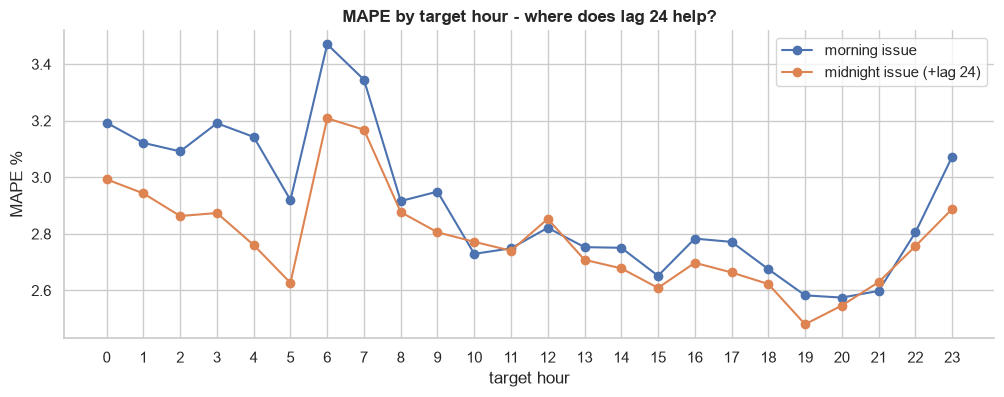

In [21]:
wm = w["P"].assign(ape=lambda d: (d.pred - d.demand_m3h).abs() / d.demand_m3h * 100)
bm = RESULTS["lgbm_trend_v2"]["P"].assign(ape=lambda d: (d.pred - d.demand_m3h).abs() / d.demand_m3h * 100)
by_hour = pd.DataFrame({"morning issue": bm.groupby(bm.target_ts.dt.hour).ape.mean(),
                        "midnight issue (+lag 24)": wm.groupby(wm.target_ts.dt.hour).ape.mean()})
ax = by_hour.plot(marker="o", figsize=(12, 4))
ax.set(title="MAPE by target hour - where does lag 24 help?", xlabel="target hour", ylabel="MAPE %",
       xticks=range(24)); plt.show()

> **Findings - lag-24 what-if**
>
> * **Issuing at midnight with real-time SCADA would cut MAPE from 2.90 % to 2.78 % (−4.2 % relative)** and the
>   daily-volume error from 1.98 % to 1.83 %.
> * The gain is concentrated in the **night and morning hours (00-08h)**, the hours closest in time to today's
>   actuals, and is close to zero in the afternoon and evening.
> * **This is a business decision, not a modelling one.** It needs the SCADA feed complete within minutes of
>   midnight and a pipeline run at ~00:30. The benefit is real but moderate: about a sixth of the gain the model
>   changes in this notebook already deliver (−24 %). **Until the issue time changes, `lag_24` must not be used.**

## 7. Error analysis of the recommended model

A model is only as good as its worst days. Where, when and why does it miss? We compare it with production
LightGBM throughout.

In [22]:
CHOSEN = board.index[0]          # best deployable model by MAPE (the what-if and interval models are excluded)
def with_errors(name):
    P = RESULTS[name]["P"].copy()
    P["err"] = P.pred - P.demand_m3h
    P["ape"] = P.err.abs() / P.demand_m3h * 100
    P["hour"], P["month"] = P.target_ts.dt.hour, P.target_ts.dt.to_period("M").astype(str)
    c = cal.set_index("date").reindex(P.target_ts.dt.normalize())
    P["day_type"] = np.select([c.holiday_name.fillna("").str.contains("Eid").to_numpy(), c.is_public_holiday.to_numpy(),
                               c.is_ramadan.to_numpy(), c.is_weekend.to_numpy()],
                              ["Eid", "other holiday", "Ramadan", "weekend"], "weekday")
    P["is_peak"] = P.demand_m3h >= P.demand_m3h.quantile(0.9)
    return P

E = with_errors(CHOSEN)
Eprod = with_errors("lgbm_prod")
print(CHOSEN, "->", RESULTS[CHOSEN]["description"])

ensemble -> mean of lgbm_trend_v2 + sarimax_daily + mlp


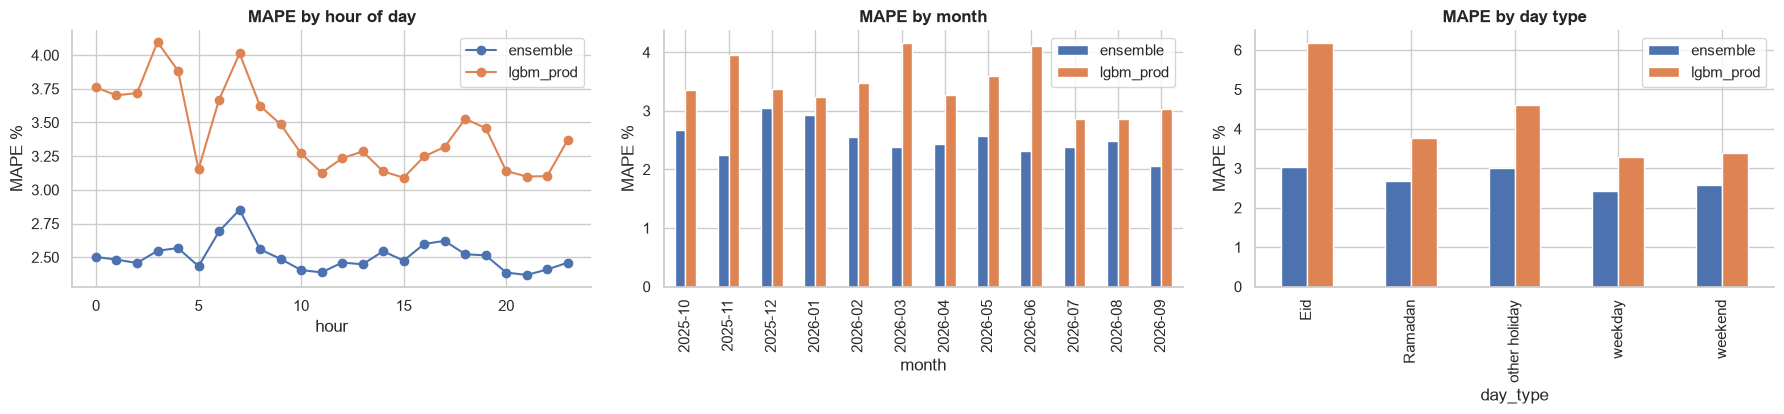

,hours,mape,bias_pct,mape_production
day_type,,,,
Eid,192,3.04,-1.59,6.19
Ramadan,647,2.68,-0.56,3.76
other holiday,168,3.00,-0.43,4.61
weekday,5467,2.43,0.02,3.29
weekend,2247,2.57,-0.15,3.39


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.3))
pd.DataFrame({CHOSEN: E.groupby("hour").ape.mean(), "lgbm_prod": Eprod.groupby("hour").ape.mean()}).plot(
    ax=axes[0], marker="o", title="MAPE by hour of day")
pd.DataFrame({CHOSEN: E.groupby("month").ape.mean(), "lgbm_prod": Eprod.groupby("month").ape.mean()}).plot.bar(
    ax=axes[1], title="MAPE by month")
dt = pd.DataFrame({CHOSEN: E.groupby("day_type").ape.mean(), "lgbm_prod": Eprod.groupby("day_type").ape.mean()})
dt.plot.bar(ax=axes[2], title="MAPE by day type")
for ax in axes:
    ax.set_ylabel("MAPE %")
plt.tight_layout(); plt.show()
seg = E.groupby("day_type").agg(hours=("ape", "size"), mape=("ape", "mean"), bias_pct=("err", lambda e: e.sum()))
seg["bias_pct"] = seg.bias_pct / E.groupby("day_type").demand_m3h.sum() * 100
seg["mape_production"] = Eprod.groupby("day_type").ape.mean()
seg.round(2)

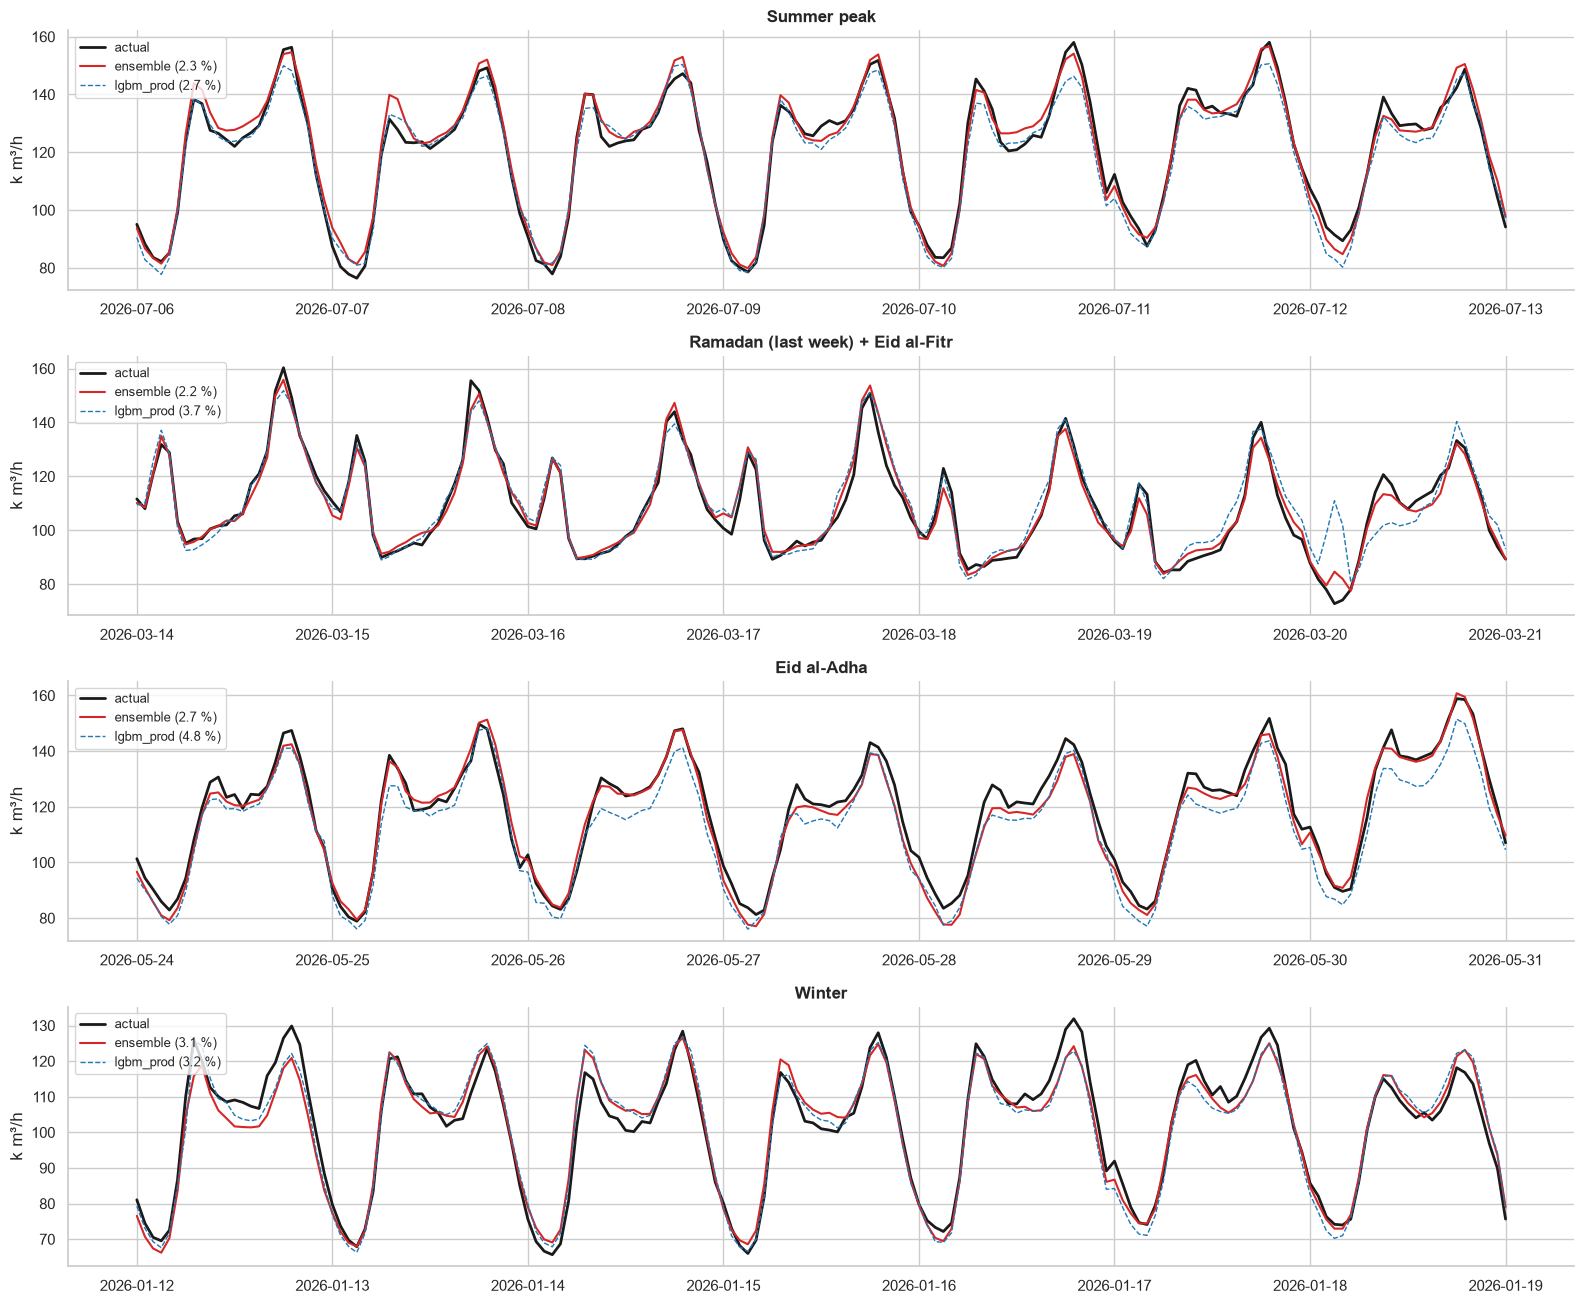

In [24]:
weeks = [("Summer peak", "2026-07-06"), ("Ramadan (last week) + Eid al-Fitr", "2026-03-14"),
         ("Eid al-Adha", "2026-05-24"), ("Winter", "2026-01-12")]
fig, axes = plt.subplots(len(weeks), 1, figsize=(16, 3.3 * len(weeks)))
for ax, (title, start) in zip(axes, weeks):
    sl = slice(pd.Timestamp(start), pd.Timestamp(start) + pd.Timedelta(days=7))
    a = E.set_index("target_ts").loc[sl]
    b = Eprod.set_index("target_ts").loc[sl]
    ax.plot(a.index, a.demand_m3h / 1e3, "k", lw=2, label="actual")
    ax.plot(a.index, a.pred / 1e3, color="tab:red", lw=1.5, label=f"{CHOSEN} ({a.ape.mean():.1f} %)")
    ax.plot(b.index, b.pred / 1e3, color="tab:blue", lw=1, ls="--", label=f"lgbm_prod ({b.ape.mean():.1f} %)")
    ax.set(title=title, ylabel="k m³/h"); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

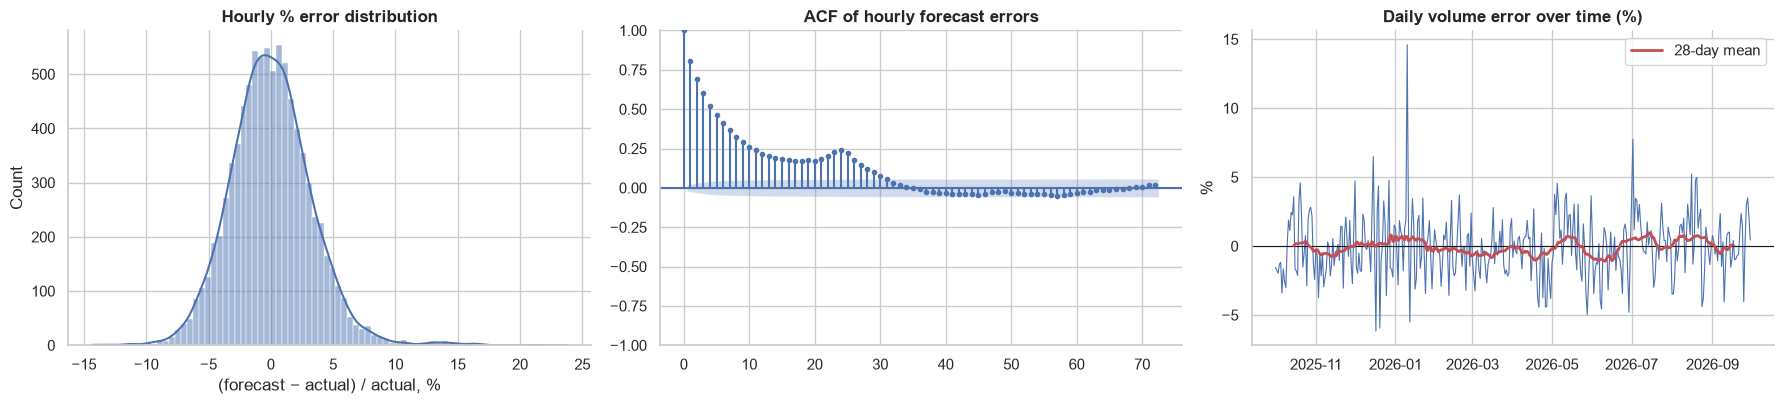

,mape,vol_err_pct,day_of_week,holiday_name,is_ramadan,tmax,rain
target_ts,,,,,,,
2026-01-10,14.58,14.60,Saturday,None,False,28.38,0.00
2026-07-02,8.09,7.74,Thursday,None,False,42.89,0.00
2025-12-15,6.50,6.49,Monday,None,False,29.47,0.00
2026-02-19,6.25,3.71,Thursday,None,True,21.05,0.00
2026-02-20,6.00,0.28,Friday,None,True,22.46,0.00
2025-12-17,5.94,-6.16,Wednesday,None,False,33.50,0.00
2025-12-20,5.69,-5.94,Saturday,None,False,33.22,0.00
2026-01-09,5.43,1.91,Friday,None,False,23.89,20.17
2025-12-01,5.39,4.72,Monday,Commemoration Day,False,30.17,0.00


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))
sns.histplot(E.err / E.demand_m3h * 100, bins=80, kde=True, ax=axes[0])
axes[0].set(title="Hourly % error distribution", xlabel="(forecast − actual) / actual, %")
plot_acf(E.set_index("target_ts").err.asfreq("h").interpolate(), lags=72, ax=axes[1], markersize=3)
axes[1].set_title("ACF of hourly forecast errors")
daily_err = E.groupby(E.target_ts.dt.normalize()).apply(lambda g: g.err.sum() / g.demand_m3h.sum() * 100)
axes[2].plot(daily_err.index, daily_err, lw=0.8); axes[2].axhline(0, color="k", lw=0.8)
axes[2].plot(daily_err.index, daily_err.rolling(28, center=True).mean(), "r", lw=2, label="28-day mean")
axes[2].set(title="Daily volume error over time (%)", ylabel="%"); axes[2].legend()
plt.tight_layout(); plt.show()
worst = E.groupby(E.target_ts.dt.normalize()).agg(mape=("ape", "mean"), vol_err_pct=("err", "sum"),
                                                   actual=("demand_m3h", "sum"))
worst["vol_err_pct"] = worst.vol_err_pct / worst.actual * 100
worst = worst.drop(columns="actual").sort_values("mape", ascending=False).head(10)
worst.join(cal.set_index("date")[["day_of_week", "holiday_name", "is_ramadan"]]).join(
    wx.groupby(wx.timestamp_local.dt.normalize()).agg(tmax=("temperature_c", "max"), rain=("precipitation_mm", "sum"))).round(2)

> **Findings - error analysis**
>
> * **Improvement is broad, and largest where production struggled.** The ensemble scores 2.43 % on weekdays,
>   2.57 % on weekends and 2.68 % in Ramadan (production 3.76 %). On **Eid days it scores 3.04 %, half of
>   production's 6.19 %**. Eid keeps a small under-forecast (bias −1.6 %).
> * **Production's Ramadan failure mode, visible in the Ramadan/Eid week:** on Eid day (20 March) production
>   forecasts a Ramadan-style pre-dawn peak that does not happen. The ensemble avoids it.
> * **Worst days:**
>   * **2026-01-10 (14.6 %)**: the unexplained drop already flagged in the EDA. No calendar, weather or event
>     explains it, which makes it a candidate for an operations-incident feed.
>   * **2026-07-02 (8.1 %)**.
>   * **The first two days of Ramadan (6.0-6.3 %)**: the intraday profile switches overnight.
>   * **A cluster of mid-December days (5.7-6.5 %)**.
> * **Errors come in day-level blocks.** The hourly error autocorrelation starts at 0.8 and bumps at 24 h: when
>   the model misses, it misses the level of a whole day, not single hours. The 28-day mean daily-volume error
>   stays within **±1.3 %** all year with no drift, so growth is handled.

## 8. What does the model rely on?

**Permutation importance by feature group:** we fit `lgbm_trend_v2` on data before 2025-10-01, then measure how
much the MAPE on the **full unseen year Oct 2025 - Sep 2026** rises when a group of features is shuffled. A full
year is needed, because a shorter window would miss Ramadan and most holidays and would wrongly rate them as
useless. Groups are more interpretable than 43 individual columns, and correlated features in a group are shuffled
together. The LightGBM split-gain ranking is shown alongside.

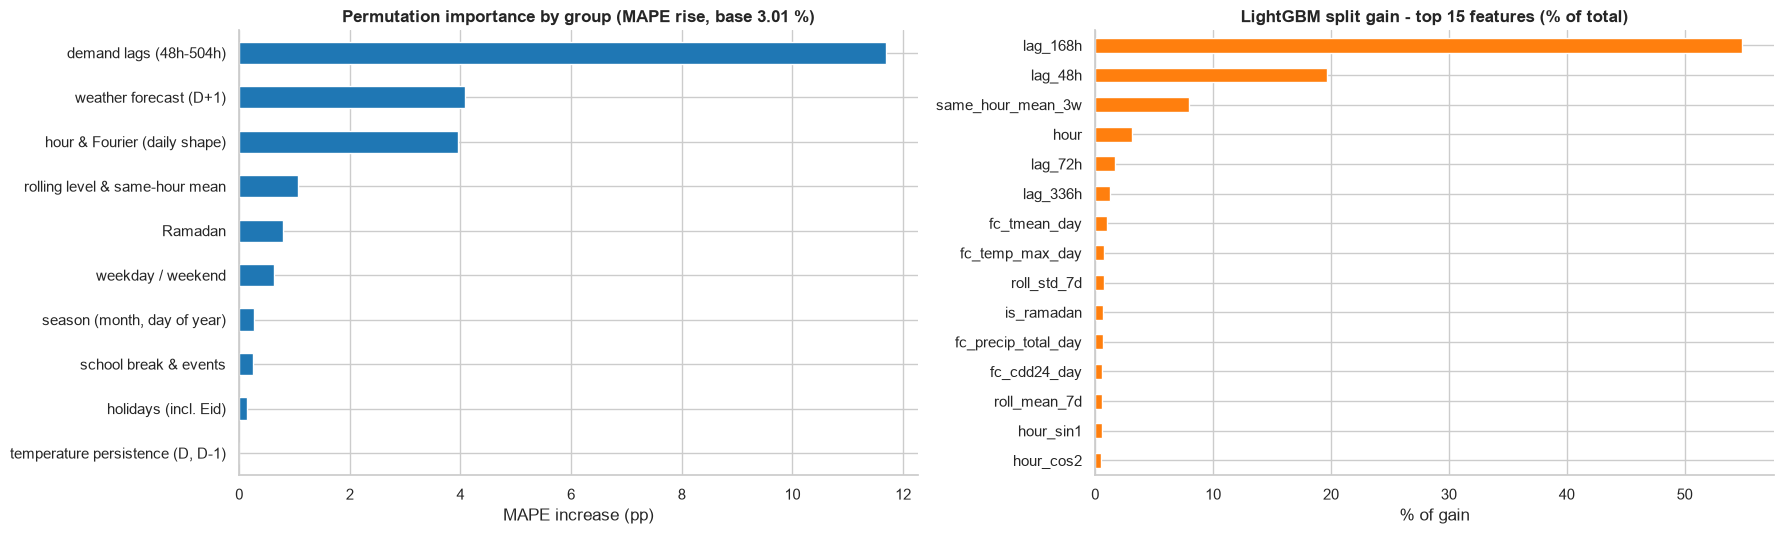

,MAPE increase (pp)
demand lags (48h-504h),11.685
weather forecast (D+1),4.081
hour & Fourier (daily shape),3.961
rolling level & same-hour mean,1.056
Ramadan,0.787
weekday / weekend,0.636
"season (month, day of year)",0.267
school break & events,0.249
holidays (incl. Eid),0.148
"temperature persistence (D, D-1)",0.001


In [26]:
split = pd.Timestamp("2025-10-01")
tr, te = data[data.target_ts < split - ONE], data[data.target_ts >= split]
model = TrendNormalized(make_model("lightgbm", lgbm_params=LGBM), V2).fit(tr, tr.demand_m3h)
base_mape = evaluate(te.demand_m3h, model.predict(te))["mape"]

groups = {
    "demand lags (48h-504h)": [c for c in V2 if c.startswith("lag_")],
    "rolling level & same-hour mean": ["roll_mean_7d", "roll_std_7d", "same_hour_mean_3w"],
    "weather forecast (D+1)": [c for c in V2 if c.startswith("fc_") and c != "fc_tmean_prev_day"],
    "temperature persistence (D, D-1)": ["fc_tmean_prev_day", "obs_tmean_d2"],
    "hour & Fourier (daily shape)": ["hour", "hour_sin1", "hour_cos1", "hour_sin2", "hour_cos2"],
    "weekday / weekend": ["day_of_week", "is_weekend", "is_day_off", "dow_sin", "dow_cos"],
    "holidays (incl. Eid)": ["is_holiday", "day_before_holiday", "day_after_holiday", "is_eid"],
    "Ramadan": ["is_ramadan", "ramadan_day"],
    "season (month, day of year)": ["month", "doy_sin", "doy_cos"],
    "school break & events": ["is_school_break"] + [c for c in V2 if c.startswith("event_")],
}
rng = np.random.default_rng(0)
imp = {}
for g, cols in groups.items():
    rises = []
    for rep in range(3):
        te_p = te.copy()
        perm = rng.permutation(len(te_p))
        te_p[cols] = te_p[cols].to_numpy()[perm]
        rises.append(evaluate(te.demand_m3h, model.predict(te_p))["mape"] - base_mape)
    imp[g] = np.mean(rises)
imp = pd.Series(imp).sort_values()

gain = pd.Series(model.model.model_.booster_.feature_importance("gain"), index=V2)
gain = (gain / gain.sum() * 100).sort_values().tail(15)
fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
imp.plot.barh(ax=axes[0], color="tab:blue")
axes[0].set(title=f"Permutation importance by group (MAPE rise, base {base_mape:.2f} %)", xlabel="MAPE increase (pp)")
gain.plot.barh(ax=axes[1], color="tab:orange")
axes[1].set(title="LightGBM split gain - top 15 features (% of total)", xlabel="% of gain")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(3).to_frame("MAPE increase (pp)")

> **Findings - explainability**
>
> Evaluated on the full unseen year. Numbers are the MAPE increase when the group is shuffled:
> * **Recent demand history (lags, +11.7 pp)** anchors level and shape; nothing else comes close.
> * **The day-ahead weather forecast (+4.1 pp)** is the main external driver, as important as the daily
>   shape itself (+4.0 pp). This is why forecast quality matters (EDA: MAE ≈ 0.9 °C).
> * **Ramadan (+0.79 pp averaged over the year)** is a large effect concentrated in ~30 days, consistent with the
>   intraday reshaping found in the EDA. The rolling level (+1.06 pp) and weekday/weekend (+0.64 pp) follow.
> * **Holidays (+0.15 pp)** and **school break / events (+0.25 pp)** are small on average because they cover few
>   days. They matter on those days (see the Eid errors above).
> * **Temperature persistence (D, D−1) adds nothing measurable (+0.001 pp)** once the day-ahead forecast is known.
>   It is a candidate for removal to simplify the feature set.

## 9. Uncertainty - prediction intervals

Operations plan against a range, not a point. Quantile LightGBM (same trend-normalised v2 setup, `objective =
quantile`, α = 0.1 and 0.9) gives an 80 % interval for every hour. It is **calibrated** if about 80 % of actuals
fall inside.

Quantile models are often **too narrow** out of sample: they learn the spread of the training period, which they
fit more closely than the future. The standard fix is **conformalised quantile regression (CQR)**:
1. On past forecasts, measure by how much the interval missed: score = max(lo − y, y − hi) / forecast.
2. Widen each new interval by the 80th percentile of those scores.

To stay honest, this runs **online**: each month is widened using only the scores of the months before it. The
first month has no history, so it is left out of the calibrated evaluation.

q10_lgbm_trend_v2        MAPE  4.19 %  bias -3.33 %  peak  5.13 %  daily 3.64 %  (84s)
q90_lgbm_trend_v2        MAPE  5.12 %  bias +4.03 %  peak  3.05 %  daily 4.30 %  (58s)
Target coverage: 80 %  (evaluated on Nov 2025 - Sep 2026)


,coverage_%,half_width_%
raw quantile model,62.4,3.7
conformal-calibrated,82.0,5.5


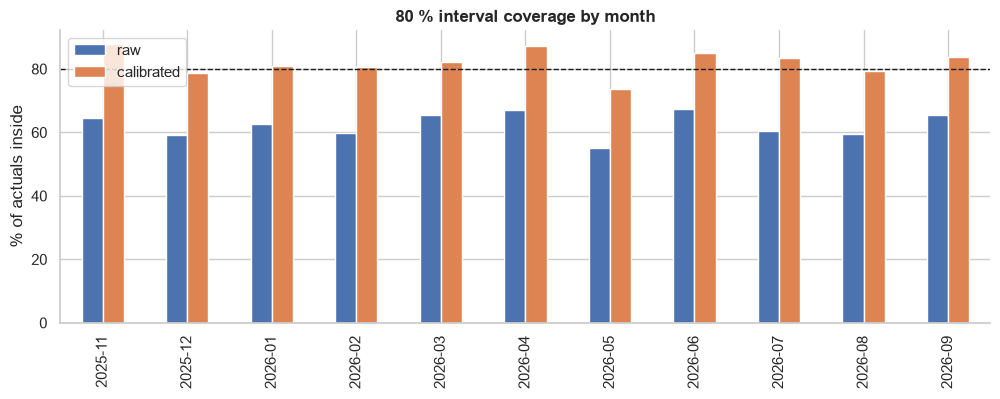

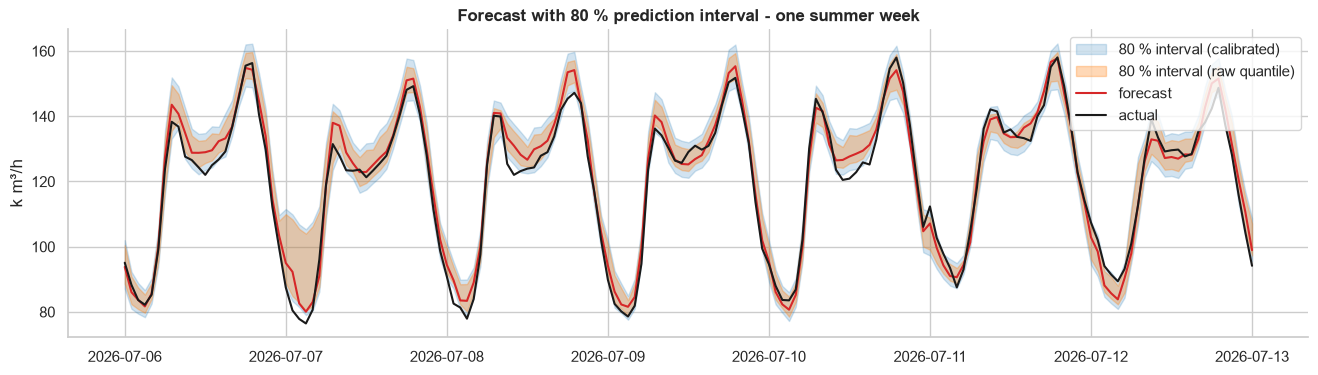

In [27]:
def quantile_model(alpha):
    return lambda: TrendNormalized(make_model("lightgbm", lgbm_params={**LGBM, "objective": "quantile", "alpha": alpha}), V2)

P10 = backtest("q10_lgbm_trend_v2", quantile_model(0.1), "interval", "quantile 0.1")
P90 = backtest("q90_lgbm_trend_v2", quantile_model(0.9), "interval", "quantile 0.9")
RESULTS.pop("q10_lgbm_trend_v2"); RESULTS.pop("q90_lgbm_trend_v2")
iv = RESULTS["lgbm_trend_v2"]["P"][["target_ts", "demand_m3h", "pred", "fold"]].copy()
iv["lo"] = iv.target_ts.map(P10.set_index("target_ts").pred)
iv["hi"] = iv.target_ts.map(P90.set_index("target_ts").pred)
iv["score"] = np.maximum(iv.lo - iv.demand_m3h, iv.demand_m3h - iv.hi) / iv.pred

for f in sorted(iv.fold.unique()):
    past = iv.loc[iv.fold < f, "score"]
    q = np.quantile(past, 0.8) if len(past) else np.nan
    m = iv.fold == f
    iv.loc[m, "lo_cal"] = iv.loc[m, "lo"] - q * iv.loc[m, "pred"]
    iv.loc[m, "hi_cal"] = iv.loc[m, "hi"] + q * iv.loc[m, "pred"]

ev = iv[iv.fold > iv.fold.min()]
summary = pd.DataFrame({
    "raw quantile model": {"coverage_%": ((ev.demand_m3h >= ev.lo) & (ev.demand_m3h <= ev.hi)).mean() * 100,
                           "half_width_%": ((ev.hi - ev.lo) / ev.pred).mean() * 50},
    "conformal-calibrated": {"coverage_%": ((ev.demand_m3h >= ev.lo_cal) & (ev.demand_m3h <= ev.hi_cal)).mean() * 100,
                             "half_width_%": ((ev.hi_cal - ev.lo_cal) / ev.pred).mean() * 50},
}).T
print("Target coverage: 80 %  (evaluated on Nov 2025 - Sep 2026)")
display(summary.round(1))
cov = pd.DataFrame({
    "raw": ev.groupby(ev.target_ts.dt.to_period("M").astype(str)).apply(lambda g: ((g.demand_m3h >= g.lo) & (g.demand_m3h <= g.hi)).mean() * 100),
    "calibrated": ev.groupby(ev.target_ts.dt.to_period("M").astype(str)).apply(lambda g: ((g.demand_m3h >= g.lo_cal) & (g.demand_m3h <= g.hi_cal)).mean() * 100),
})
ax = cov.plot.bar(figsize=(12, 3.8)); ax.axhline(80, color="k", ls="--", lw=1)
ax.set(title="80 % interval coverage by month", ylabel="% of actuals inside", xlabel=""); plt.show()

sl = slice(pd.Timestamp("2026-07-06"), pd.Timestamp("2026-07-13"))
w8 = iv.set_index("target_ts").loc[sl]
fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(w8.index, w8.lo_cal / 1e3, w8.hi_cal / 1e3, alpha=0.2, color="tab:blue", label="80 % interval (calibrated)")
ax.fill_between(w8.index, w8.lo / 1e3, w8.hi / 1e3, alpha=0.3, color="tab:orange", label="80 % interval (raw quantile)")
ax.plot(w8.index, w8.pred / 1e3, color="tab:red", lw=1.5, label="forecast")
ax.plot(w8.index, w8.demand_m3h / 1e3, "k", lw=1.5, label="actual")
ax.set(title="Forecast with 80 % prediction interval - one summer week", ylabel="k m³/h"); ax.legend(); plt.show()

> **Findings - uncertainty**
>
> * **The raw quantile model is over-confident:** its "80 %" interval contains only **62.4 %** of actuals.
> * **Online conformal calibration fixes it: 82.0 % coverage** (target 80 %), at ±5.5 % half-width (raw: ±3.7 %).
>   Each month uses only the errors of the months before it, so this is what production would achieve.
> * **Recommendation:** publish calibrated P10/P90 bands next to the point forecast, recalibrated nightly from the
>   monitoring table. Planned as a follow-up (it needs two extra quantile models per training run).

## 10. Hand-off check: does the production code reproduce these results?

The recommended models were re-implemented in `src/water_forecasting/modeling.py` as the training-pipeline
candidates `lightgbm_trend`, `ridge_interactions` and `blend_ridge_lgbm`, and the v2 features in
`features.py`. Here the **production classes are imported and backtested unchanged**, on the production feature
frame (`features.model_columns()`, which adds the trend index `t_days`). If the numbers match the notebook
versions above, what ships is what was validated.

In [28]:
from water_forecasting.modeling import make_model as production_model

MODEL_COLS = F.model_columns()
for fam in ["lightgbm_trend", "ridge_interactions", "blend_ridge_lgbm"]:
    backtest(f"PROD_{fam}", lambda fam=fam: OnCols(production_model(fam, cfg.model.ridge_alpha, LGBM), MODEL_COLS),
             "production code", f"src make_model('{fam}')")
handoff = pd.DataFrame({
    "notebook implementation": {"lightgbm_trend": RESULTS["lgbm_trend_v2"]["metrics"]["mape"],
                                "ridge_interactions": RESULTS["ridge_interactions"]["metrics"]["mape"],
                                "blend_ridge_lgbm": np.nan},
    "production code (src)": {f: RESULTS[f"PROD_{f}"]["metrics"]["mape"] for f in
                              ["lightgbm_trend", "ridge_interactions", "blend_ridge_lgbm"]},
})
handoff["difference_pp"] = handoff["production code (src)"] - handoff["notebook implementation"]
prod_metrics = pd.DataFrame({f: RESULTS.pop(f"PROD_{f}")["metrics"] for f in
                             ["lightgbm_trend", "ridge_interactions", "blend_ridge_lgbm"]}).T
display(handoff.round(3))
prod_metrics[["mape", "bias_pct", "peak_mape", "daily_total_ape"]].round(2)

PROD_lightgbm_trend      MAPE  2.90 %  bias +0.16 %  peak  2.66 %  daily 1.98 %  (37s)
PROD_ridge_interactions  MAPE  2.64 %  bias +0.12 %  peak  2.61 %  daily 1.89 %  (5s)
PROD_blend_ridge_lgbm    MAPE  2.61 %  bias +0.14 %  peak  2.55 %  daily 1.82 %  (35s)


,notebook implementation,production code (src),difference_pp
lightgbm_trend,2.902,2.902,0.0
ridge_interactions,2.639,2.639,0.0
blend_ridge_lgbm,NaN,2.605,NaN


,mape,bias_pct,peak_mape,daily_total_ape
lightgbm_trend,2.90,0.16,2.66,1.98
ridge_interactions,2.64,0.12,2.61,1.89
blend_ridge_lgbm,2.61,0.14,2.55,1.82


> **Findings - hand-off**
>
> * **The production code reproduces the notebook exactly (difference 0.000 pp)** for `lightgbm_trend` (2.90 %)
>   and `ridge_interactions` (2.64 %).
> * **`blend_ridge_lgbm` reaches 2.61 % MAPE**: bias +0.14 %, peak-hour 2.55 %, daily volume 1.82 %. That is
>   better than either member and **24 % below production**, with no new runtime dependency (scikit-learn +
>   LightGBM only).
> * All three are now candidates in `project_config.yml`. The weekly training job fits every candidate, keeps the
>   best on a fresh 28-day holdout, and promotes it to `@champion` only if it beats the current champion by ≥ 1 %.

## 11. Conclusions and recommendation (for review)

### What was learned
| | MAPE | vs production | comment |
|---|---|---|---|
| Production today (LightGBM, raw target) | 3.44 % | - | biased −1.34 %: under-forecasts a growing city |
| **Shipped with this change: `blend_ridge_lgbm`** | **2.61 %** | **−24 %** | growth-aware; same runtime stack |
| Best found: ensemble (LightGBM-trend + SARIMAX + MLP) | 2.51 % | −27 % | needs PyTorch + a daily SARIMAX pipeline |
| What-if: midnight issue with `lag_24` | 2.78 % (vs 2.90 %) | −4.2 % relative | needs a business decision on the issue time |

### Recommendations for review
1. **Adopt the growth-aware candidates (implemented in this change).** `lightgbm_trend`, `ridge_interactions` and
   `blend_ridge_lgbm` are now training candidates. Expected: MAPE ≈ 2.6 % (−24 %), bias from −1.3 % to +0.1 %,
   peak-hour MAPE 4.0 → 2.6 %, Eid-day errors roughly halved. Champion/challenger still guards every promotion.
2. **Phase 2 - add the MLP as a candidate** to reach the ensemble level (~2.5 %). Cost: PyTorch in the job
   environment and 3-seed training. **Not recommended now:** the GRU seq2seq (no accuracy gain over the MLP at
   ~5× the compute) and Random Forest (worse than production). SARIMAX is a good interpretable challenger if a
   daily top-down pipeline is ever wanted.
3. **Decide the issue time** (Section 6). Midnight issue plus real-time SCADA gives a further −4.2 %. Until then,
   the 48-hour minimum lag stays.
4. **Publish calibrated P10/P90 intervals** (Section 9, conformal calibration: 82 % coverage for a nominal 80 %).
5. **Data quality:** the stuck-meter rule found in the EDA is now part of the production quality gate.
6. **Watch-list for monitoring:** first days of Ramadan, Eid days, and unexplained level drops such as
   2026-01-10. An operations-incident feed (planned outages, pressure management) would be the next data
   source to add.

### Limitations
* One test year (Oct 2025 - Sep 2026), albeit covering every season, Ramadan and both Eids. Monthly refits are
  slightly conservative compared with production's weekly retraining.
* The source data and its weather forecast are realistic simulations. Accuracy on the client's live SCADA feed
  must be confirmed in the first weeks of operation, which the monitoring job measures from day one.
* The ensemble's members were fixed by design, not by result. The post-hoc best combinations reach ~2.45 %, but
  choosing them on this test year would overfit it.